STARTING PIPELINE: Breast Cancer Classification

STEP 1: FRAME THE PROBLEM
Dataset metadata: {'numRows': 569, 'numColumns': 31, 'missingValuesByColumn': {'mean_radius': 0, 'mean_texture': 0, 'mean_perimeter': 0, 'mean_area': 0, 'mean_smoothness': 0, 'mean_compactness': 0, 'mean_concavity': 0, 'mean_concave_points': 0, 'mean_symmetry': 0, 'mean_fractal_dimension': 0, 'radius_error': 0, 'texture_error': 0, 'perimeter_error': 0, 'area_error': 0, 'smoothness_error': 0, 'compactness_error': 0, 'concavity_error': 0, 'concave_points_error': 0, 'symmetry_error': 0, 'fractal_dimension_error': 0, 'worst_radius': 0, 'worst_texture': 0, 'worst_perimeter': 0, 'worst_area': 0, 'worst_smoothness': 0, 'worst_compactness': 0, 'worst_concavity': 0, 'worst_concave_points': 0, 'worst_symmetry': 0, 'worst_fractal_dimension': 0, 'target': 0}, 'sampleOfRows':    mean_radius  mean_texture  mean_perimeter  mean_area  mean_smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   

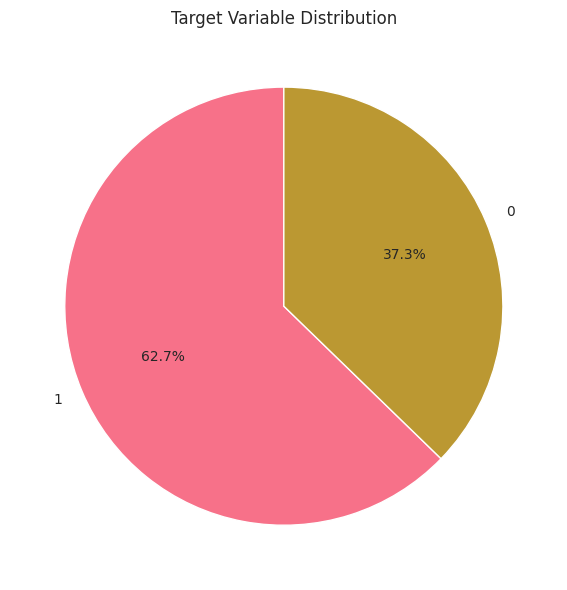

   Visualizing target distribution


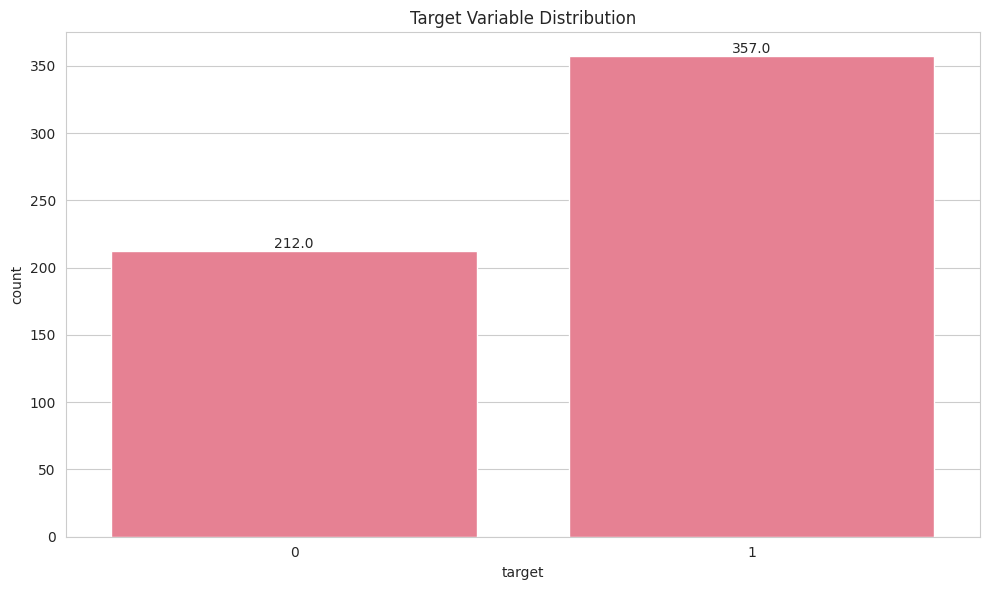

5. Visualizing numeric attributes (histograms + KDE)


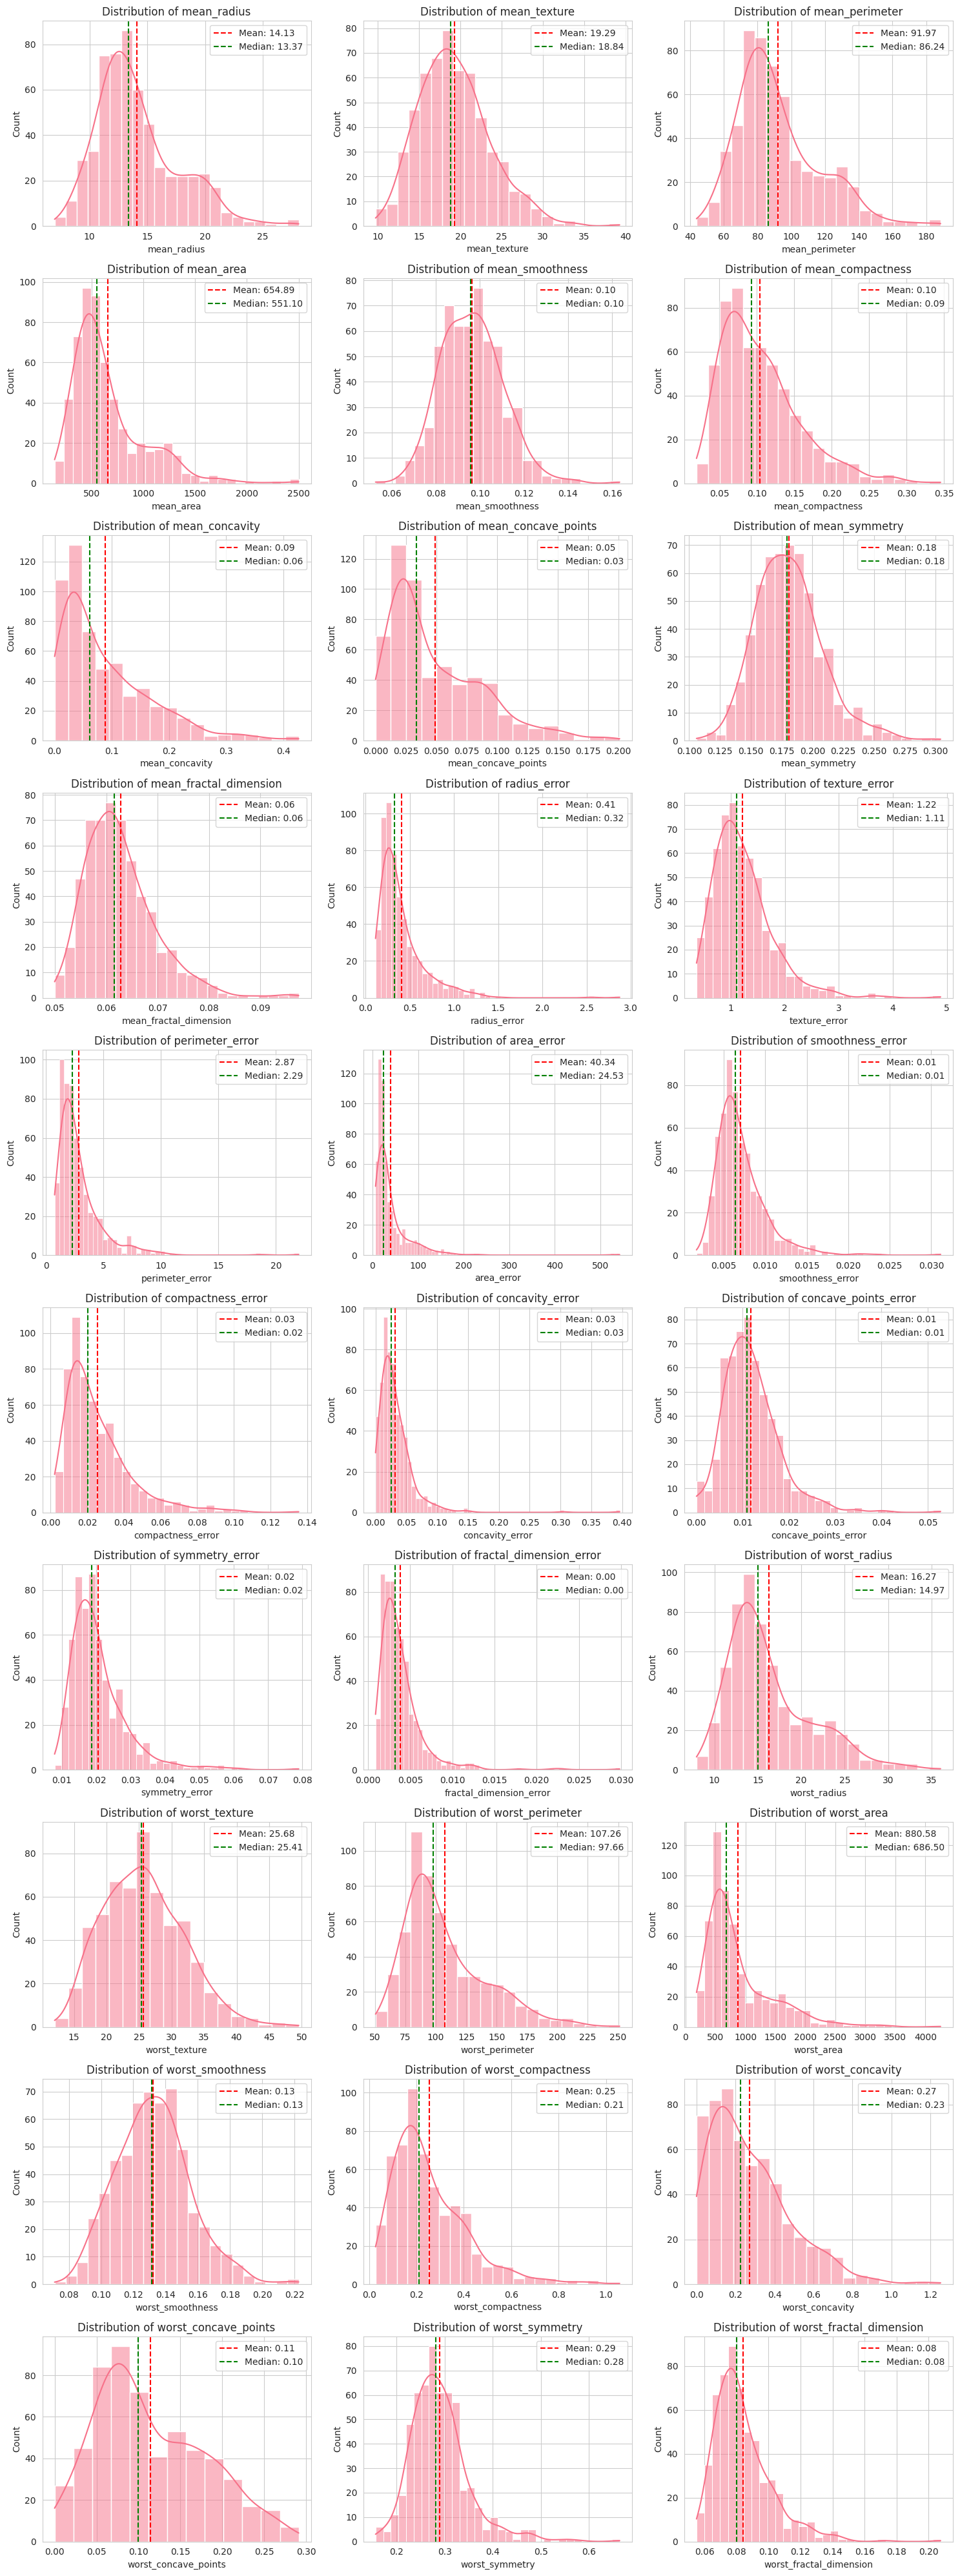

   Visualizing boxplots of features by target


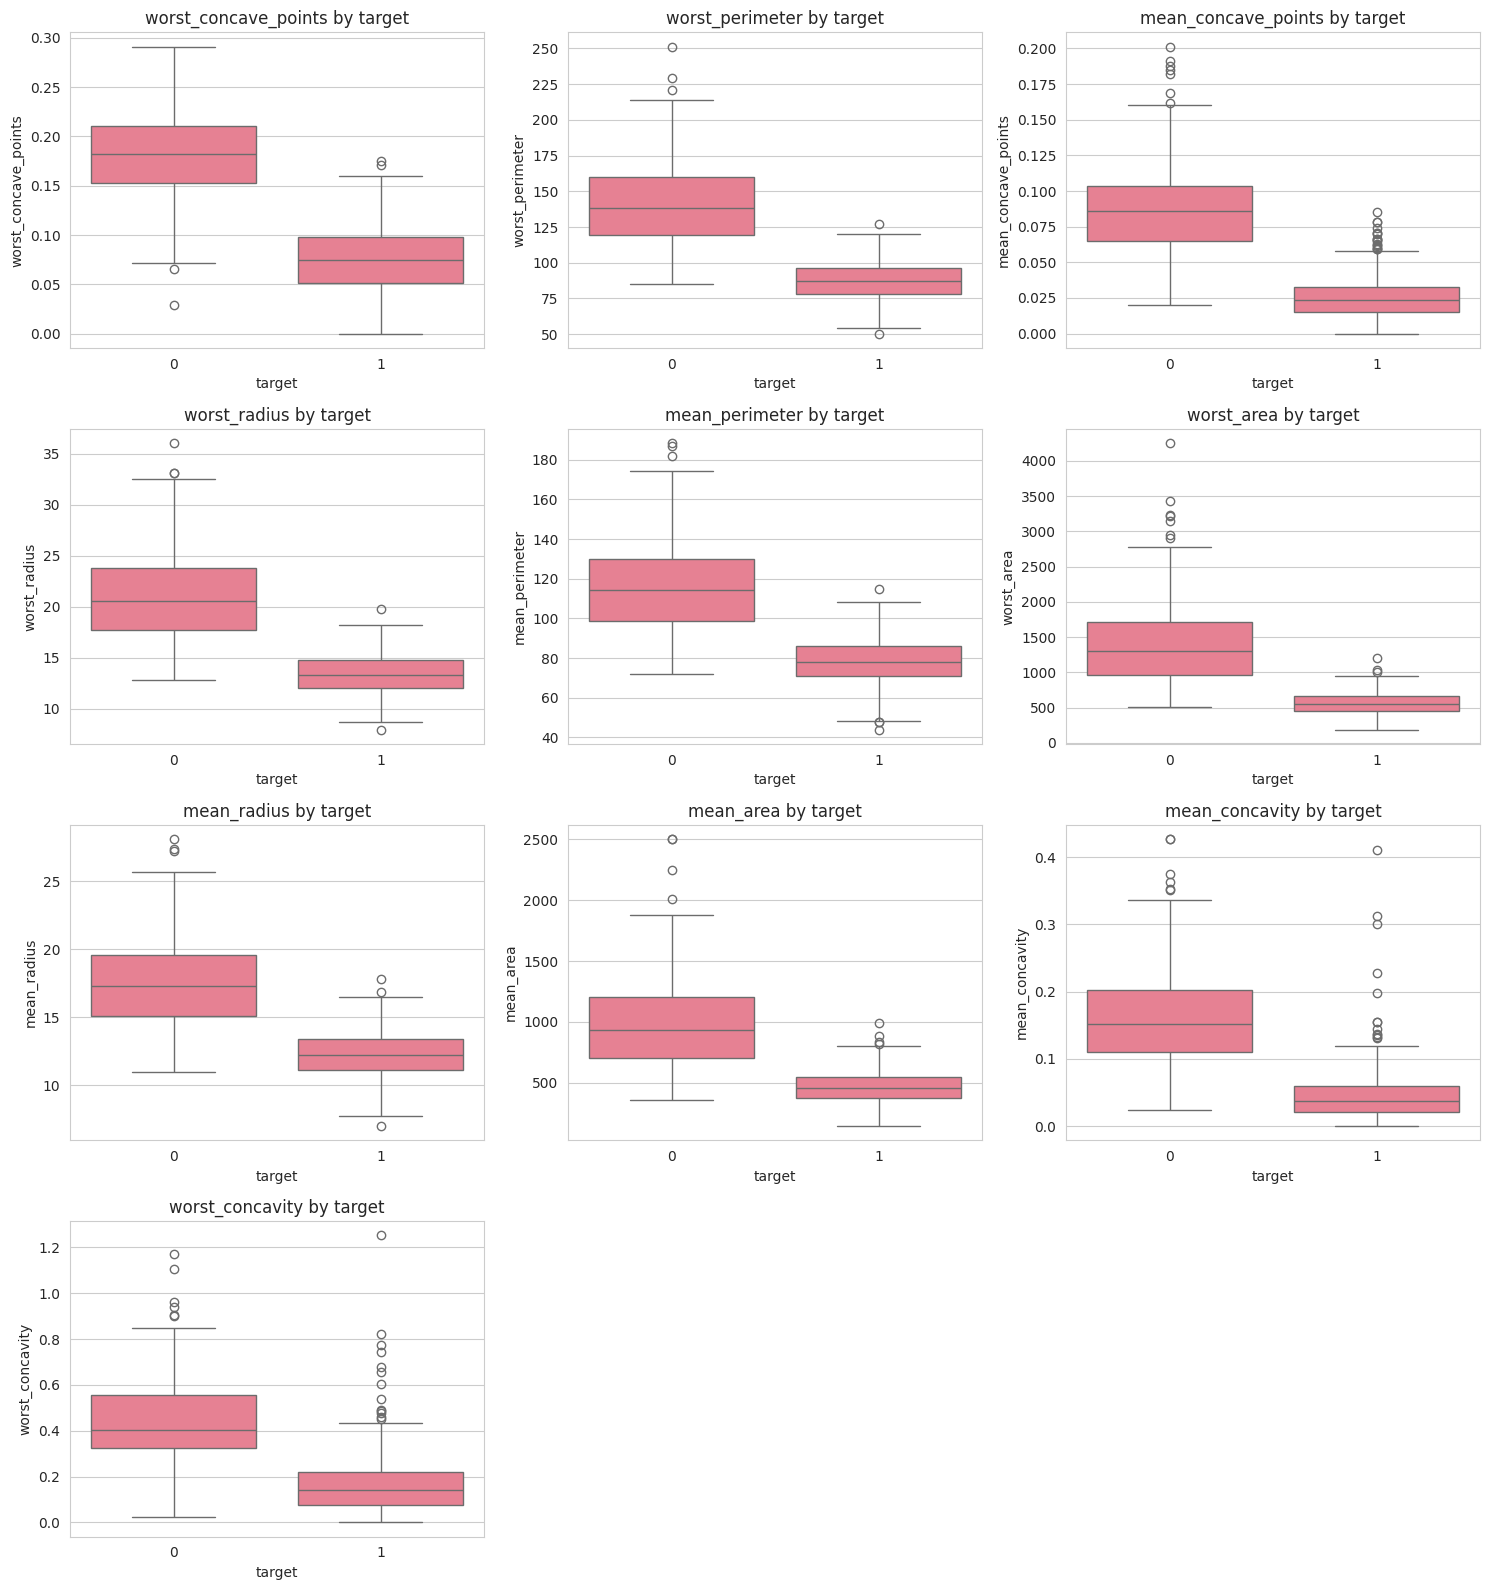

6. Studying correlations between attributes


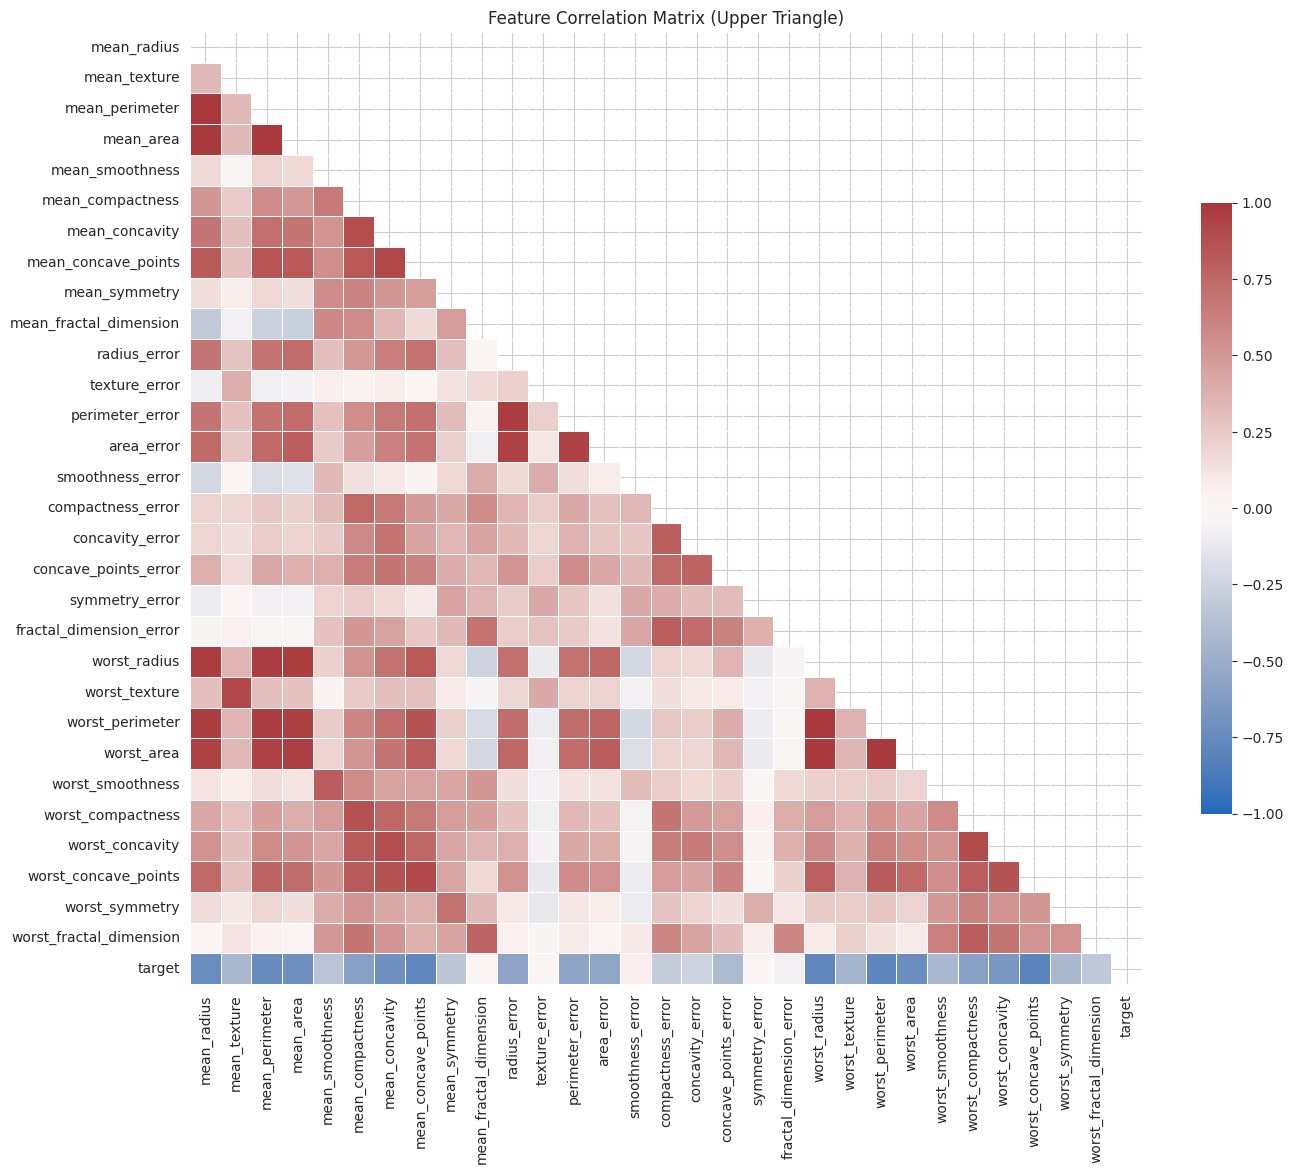

   Top features correlated with target (absolute correlation):


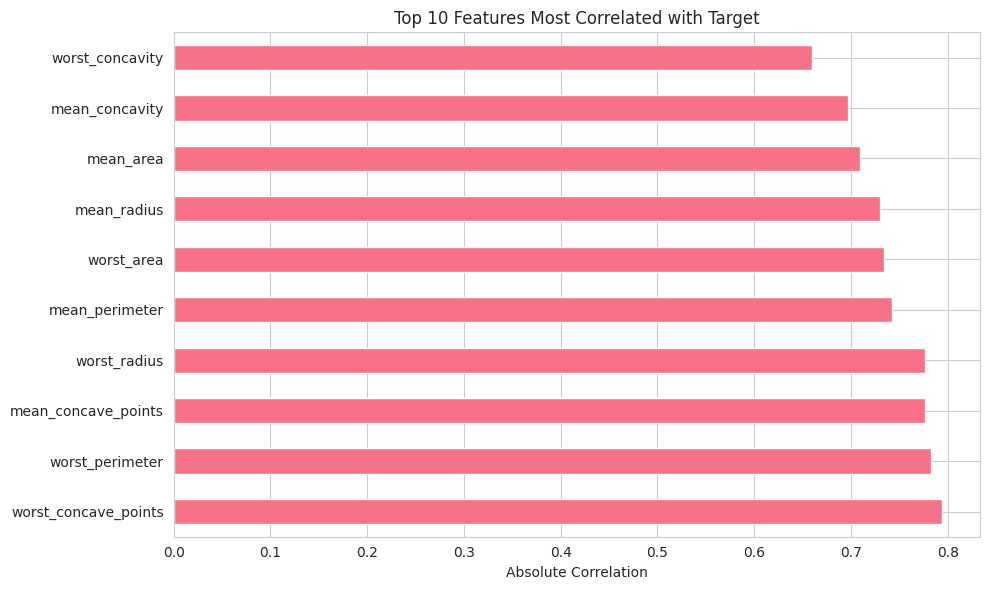

   Visualizing pairplot of most important features


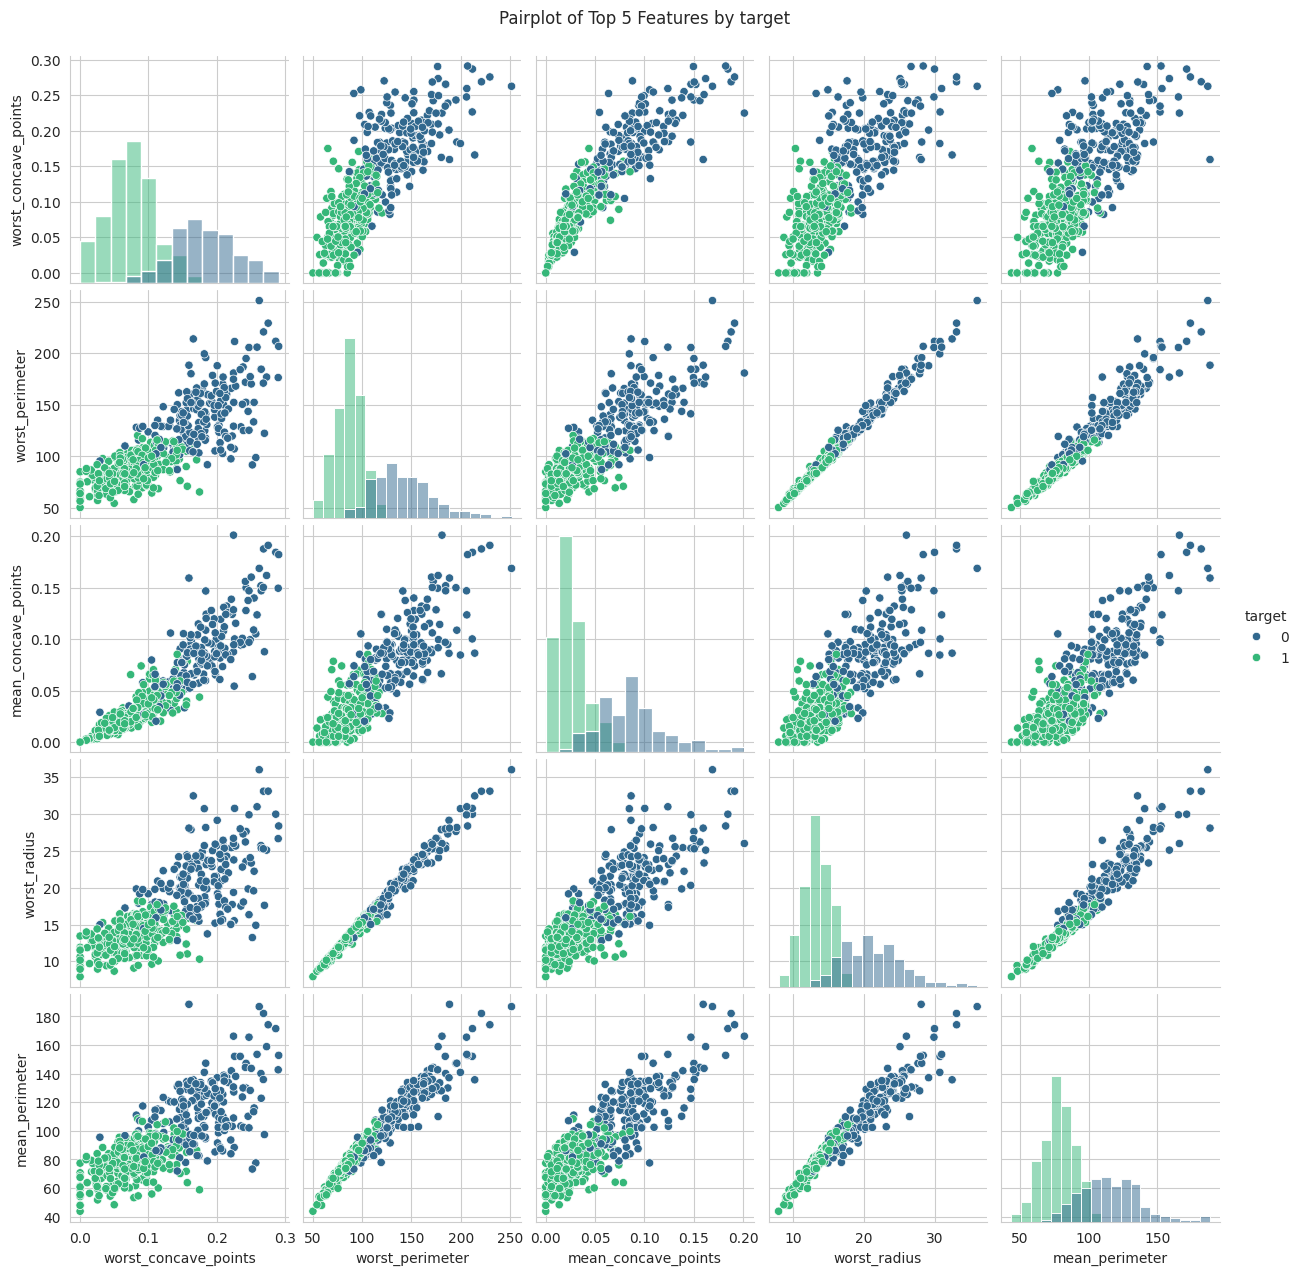

7. Studying how to solve manually with domain expertise
   Manual solution sketch recorded
8. Identifying promising transformations
   Suggested transformations
9. Identifying useful additional data
   Additional data suggested: ['patient_demographics', 'family_history', 'genetic_markers', 'multi-modal_image_metadata']
10. Documenting what was learned during EDA
[DEBUG] Complete EDA pipeline
EDA findings: {'targetColumn': 'target', 'targetIsCategorical': True, 'targetDistributionSample': {1: 357, 0: 212}, 'topCorrelatedWithTarget': {'worst_concave_points': 0.79356601714127, 'worst_perimeter': 0.7829141371737594, 'mean_concave_points': 0.7766138400204369, 'worst_radius': 0.77645377859504, 'mean_perimeter': 0.7426355297258337, 'worst_area': 0.7338250349210507, 'mean_radius': 0.7300285113754563, 'mean_area': 0.7089838365853907, 'mean_concavity': 0.6963597071719053, 'worst_concavity': 0.6596102103692335}, 'manualSolutionSketch': 'Specialized inspection of radius, texture, perimeter and con

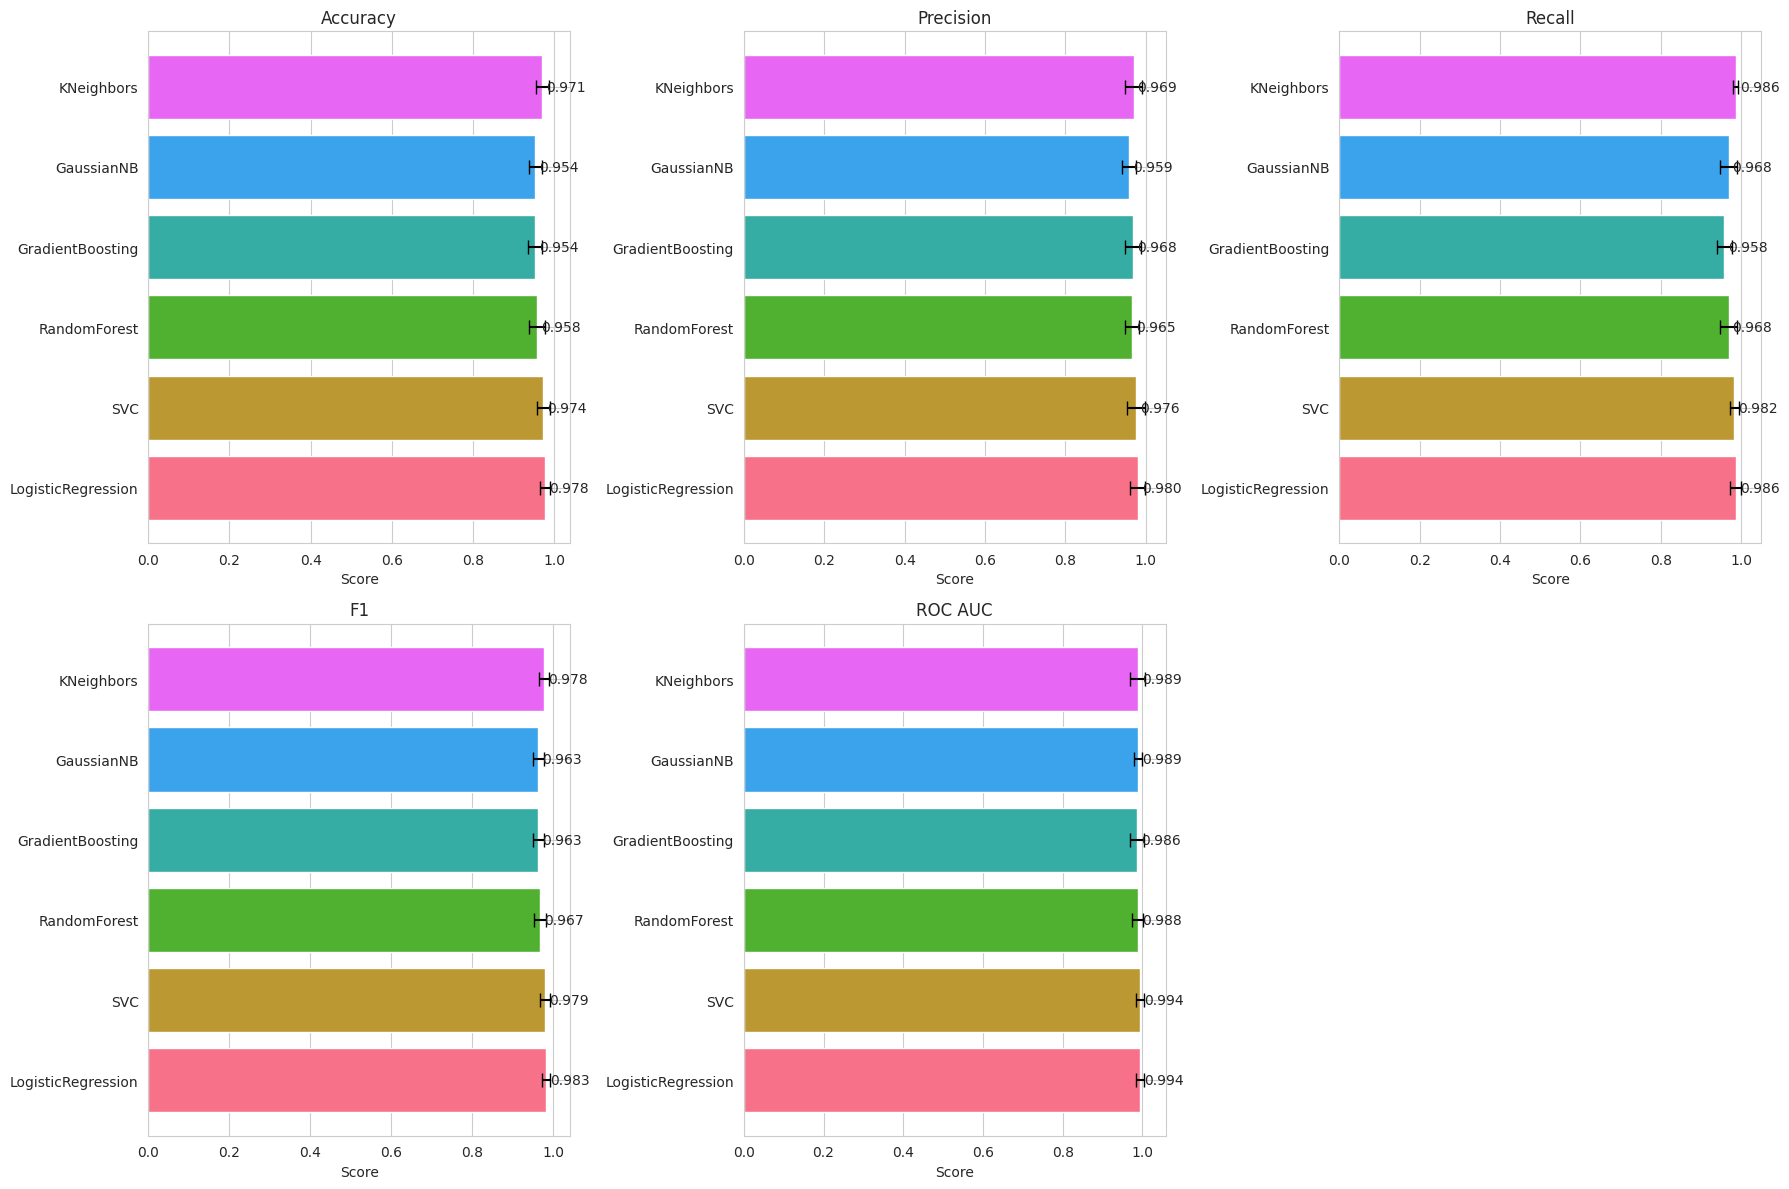

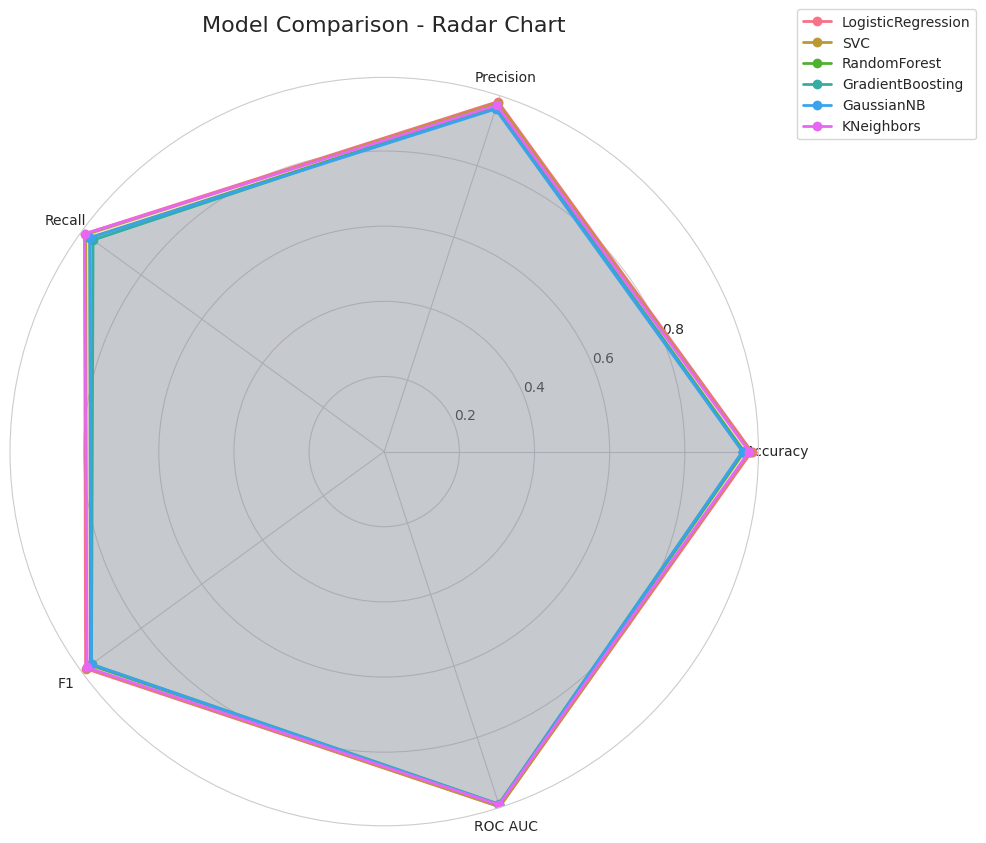


STEP 6: TUNE MODELS
Tuning hyperparameters...
  Tuning SVC...
    Best parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}
    Best score: 0.9950
  Tuning LogisticRegression...
    Best parameters: {'solver': 'saga', 'penalty': 'l2', 'C': 0.1}
    Best score: 0.9944
Creating ensemble...
Evaluating final model...
Performance on test set:
  accuracy: 0.9825
  precision: 0.9861
  recall: 0.9861
  f1: 0.9861
  roc_auc: 0.9957
Plotting ROC curve...


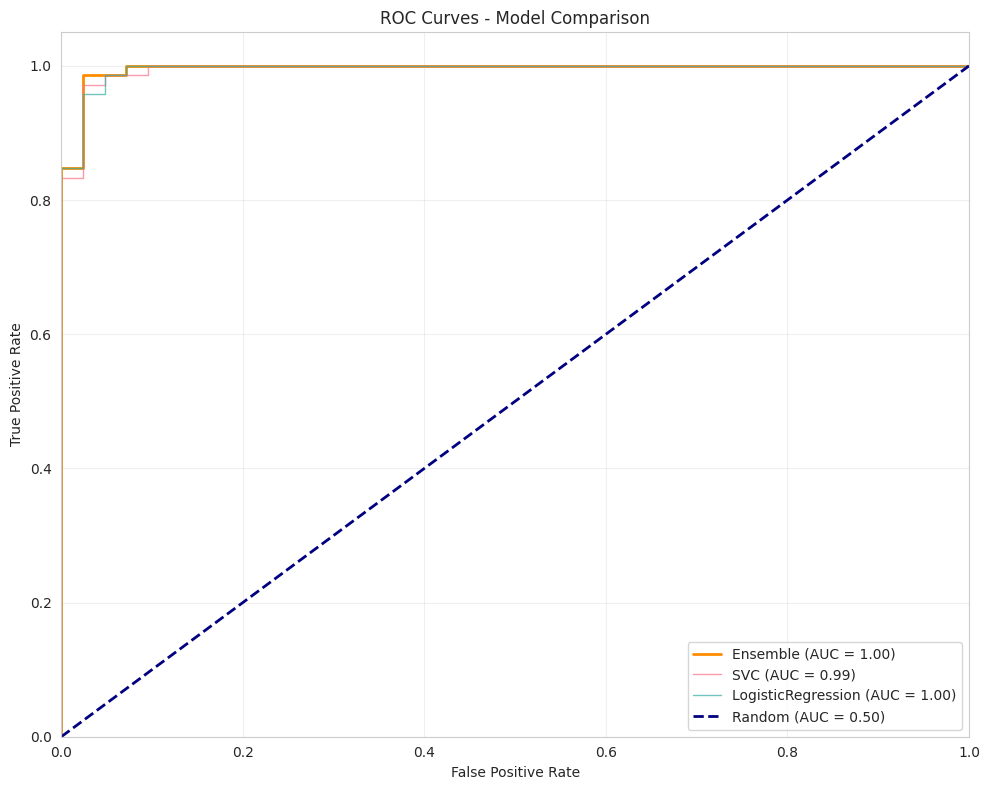

Plotting Precision-Recall curve...


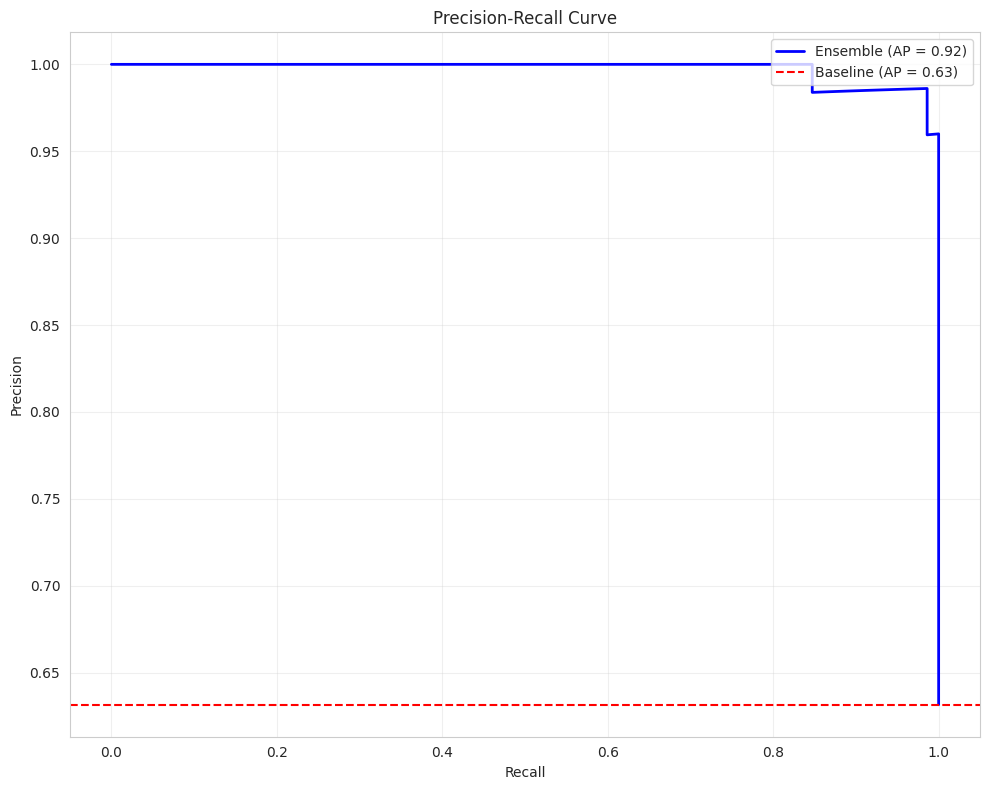

Plotting confusion matrix...


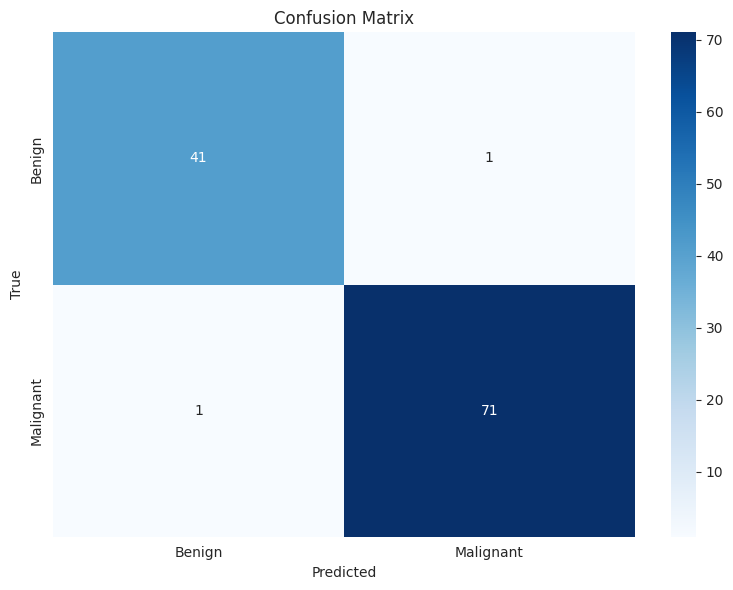

Plotting feature importance...
No tree-based model found to plot feature importance.
Plotting learning curve...


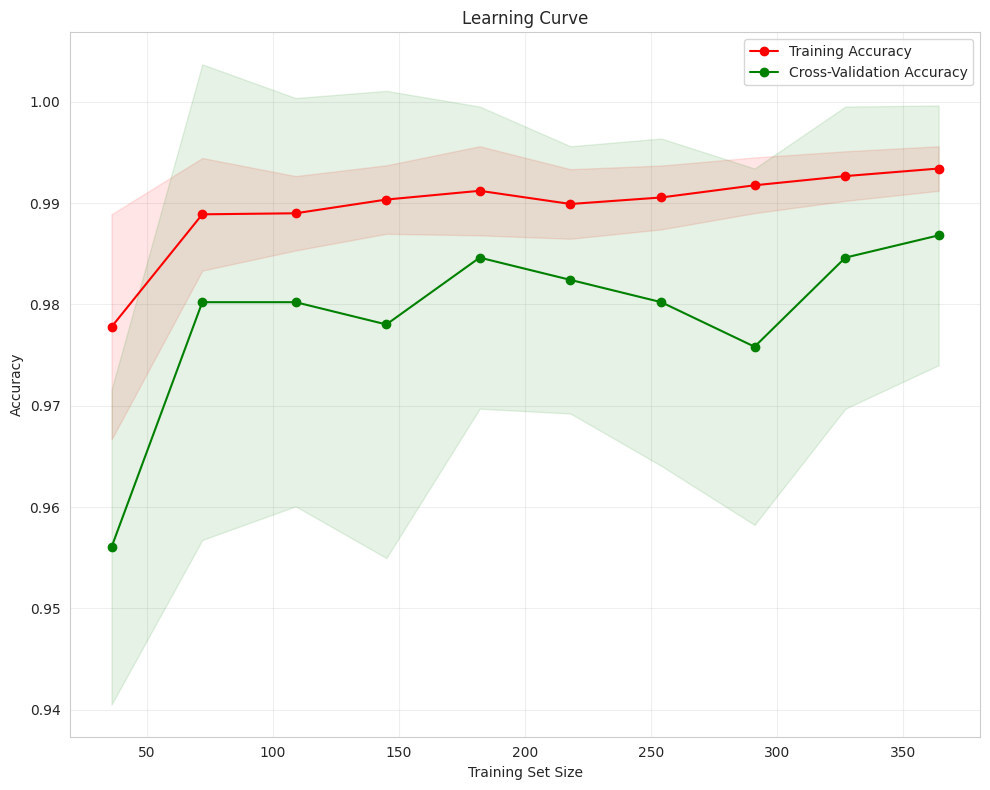


STEP 7: PRESENT SOLUTION
Saving reports...
Creating executive summary...
Creating detailed report...
Reports saved in directory: reports

PIPELINE COMPLETED SUCCESSFULLY!


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve, validation_curve
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_curve, auc, confusion_matrix, precision_recall_curve,
                             classification_report, RocCurveDisplay, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_validate, RandomizedSearchCV
from typing import Optional, Dict, Any, List, Tuple
import warnings
warnings.filterwarnings('ignore')

# Global settings
RANDOM_STATE = 42
DPI = 300  # Resolution for saving images
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)

class ProblemFramer:
    """
    Class to frame the problem and understand the project's overall scope.
    """
    def __init__(self, dataset_dataframe: Optional[pd.DataFrame] = None,
                 target_column_name: Optional[str] = None,
                 id_column_name: Optional[str] = None):
        self.dataset_dataframe = dataset_dataframe
        self.target_column_name = target_column_name
        self.id_column_name = id_column_name

        # Helper functions
        self._is_categorical = lambda series: (series.dtype == object) or (series.nunique() <= 30)
        self._safe_div = lambda a, b: a / b if b != 0 else np.nan

    def ingest_dataset(self, dataframe: pd.DataFrame,
                      target_column_name: Optional[str] = None,
                      id_column_name: Optional[str] = None) -> None:
        self.dataset_dataframe = dataframe.copy()
        if target_column_name:
            self.target_column_name = target_column_name
        if id_column_name:
            self.id_column_name = id_column_name

    def summarize_dataset_metadata(self) -> Dict[str, Any]:
        if self.dataset_dataframe is None:
            raise ValueError("No dataset loaded. Call ingest_dataset() first.")

        num_rows = len(self.dataset_dataframe)
        num_columns = len(self.dataset_dataframe.columns)
        missing_values = self.dataset_dataframe.isnull().sum().to_dict()
        sample_of_rows = self.dataset_dataframe.head(5)

        id_column_is_unique = None
        if self.id_column_name and self.id_column_name in self.dataset_dataframe.columns:
            id_column_is_unique = self.dataset_dataframe[self.id_column_name].is_unique

        return {
            "numRows": num_rows,
            "numColumns": num_columns,
            "missingValuesByColumn": missing_values,
            "sampleOfRows": sample_of_rows,
            "idColumnIsUnique": id_column_is_unique
        }

    def infer_task_type(self) -> Dict[str, Any]:
        if self.dataset_dataframe is None or self.target_column_name is None:
            return {"inferredTask": "unknown", "isTargetCategorical": None, "classDistribution": None}

        if self.target_column_name not in self.dataset_dataframe.columns:
            raise KeyError(f"Target column '{self.target_column_name}' not found in dataset")

        target_series = self.dataset_dataframe[self.target_column_name]
        is_categorical_flag = bool(self._is_categorical(target_series))
        inferred_task = "classification" if is_categorical_flag else "regression"
        result = {"inferredTask": inferred_task, "isTargetCategorical": is_categorical_flag}

        if is_categorical_flag:
            distribution = target_series.value_counts(dropna=False).to_dict()
            class_counts = distribution
            total_count = len(target_series)
            class_proportions = {k: (v, round(self._safe_div(v, total_count), 4))
                                for k, v in class_counts.items()}
            result["classDistribution"] = class_proportions

        return result

    def propose_performance_metrics(self) -> Dict[str, str]:
        inferred = self.infer_task_type().get("inferredTask", "unknown")

        if inferred == "classification":
            primary_metric = "roc_auc"
            secondary_metric = "f1_score"
            rationale_text = "Use ROC AUC for overall separability and F1 for class balance and operational trade-offs."
        elif inferred == "regression":
            primary_metric = "root_mean_squared_error"
            secondary_metric = "mean_absolute_error"
            rationale_text = "Use RMSE to penalize large errors and MAE for interpretable average error."
        elif inferred == "unknown":
            primary_metric = "tbd"
            secondary_metric = "tbd"
            rationale_text = "Unable to infer task: provide target column or specify task type."
        else:
            primary_metric = "tbd"
            secondary_metric = "tbd"
            rationale_text = "For clustering consider silhouette_score and adjusted_mutual_info_score if ground truth exists."

        return {
            "recommendedPrimaryMetric": primary_metric,
            "recommendedSecondaryMetric": secondary_metric,
            "rationale": rationale_text
        }

    def suggest_minimum_acceptable_performance(self,
                                              baseline_performance_value: Optional[float] = None) -> Dict[str, Any]:
        inferred = self.infer_task_type().get("inferredTask", "unknown")

        if baseline_performance_value is None:
            suggestion = None
            explanation = "No baseline provided; please provide existing performance or business target to suggest minimum."
        else:
            if inferred == "classification":
                suggested_minimum = round(min(0.99, baseline_performance_value * 1.02), 4)
                suggestion = suggested_minimum
                explanation = "I suggest improving the current baseline by ~2% relative when feasible."
            elif inferred == "regression":
                suggested_minimum = round(max(0.0, baseline_performance_value * 0.98), 4)
                suggestion = suggested_minimum
                explanation = "I suggest reducing RMSE by ~2% relative when feasible."
            else:
                suggestion = None
                explanation = "Unknown task; cannot automatically propose numerical minimum."

        return {"suggestedMinimum": suggestion, "explanation": explanation}

    def list_checklist_items_not_applicable(self, custom_notes: Optional[str] = None) -> Dict[str, Any]:
        note_text = custom_notes if custom_notes else "No exceptions recorded."
        return {"justifications": note_text}


class DataManager:
    """
    Manages data acquisition and initial preparation.
    """
    def __init__(self, workspace_directory_path: str = "wdbc_workspace",
                 preferred_kaggle_dataset_slug: str = "uciml/breast-cancer-wisconsin-data",
                 desired_test_ratio: float = 0.2,
                 random_state: int = RANDOM_STATE):
        self.workspace_directory_path = Path(workspace_directory_path)
        self.raw_data_directory_path = self.workspace_directory_path / "raw"
        self.processed_data_directory_path = self.workspace_directory_path / "processed"
        self.preferred_kaggle_dataset_slug = preferred_kaggle_dataset_slug
        self.desired_test_ratio = desired_test_ratio
        self.random_state = random_state

        # Outputs to be filled
        self.dataFrame: Optional[pd.DataFrame] = None
        self.target_variable: Optional[str] = None
        self.X_train: Optional[pd.DataFrame] = None
        self.X_test: Optional[pd.DataFrame] = None
        self.y_train: Optional[pd.Series] = None
        self.y_test: Optional[pd.Series] = None

        # Helper functions
        self._is_csv = lambda filename: str(filename).lower().endswith(".csv")
        self._make_path = lambda p: Path(p)
        self._ensure_dir = lambda p: Path(p).mkdir(parents=True, exist_ok=True)

    def _ensure_workspace(self) -> None:
        for directory in (self.workspace_directory_path, self.raw_data_directory_path, self.processed_data_directory_path):
            self._ensure_dir(directory)

    def _fallback_load_from_sklearn(self) -> pd.DataFrame:
        payload = load_breast_cancer()
        df = pd.DataFrame(payload.data, columns=[c.replace(" ", "_") for c in payload.feature_names])
        df["target"] = payload.target
        return df

    def _identify_and_set_target(self, dataframe: pd.DataFrame,
                                potential_targets: Optional[List[str]] = None) -> str:
        potential_targets = potential_targets or ['target', 'diagnosis', 'class', 'outcome']
        for candidate in potential_targets:
            if candidate in dataframe.columns:
                return candidate
        fallback = dataframe.columns[-1]
        return fallback

    def _encode_target_if_needed(self, y_series: pd.Series) -> pd.Series:
        if y_series.dtype == object or y_series.dtype.name == "category":
            unique_vals = y_series.unique()
            mapping = {v: i for i, v in enumerate(sorted(unique_vals))}
            return y_series.map(lambda v: mapping[v]).astype(int)
        return y_series

    def get_data(self) -> None:
        print("1. Listing the data you need and how much you need.")
        print("   Required: Breast cancer diagnosis data with 30 numeric features computed from FNA images. Need at least several hundred samples for robust cross-validation.")

        print("\n2. Finding and documenting where you can get this data.")
        print(f"   Preferred source: Kaggle dataset slug: {self.preferred_kaggle_dataset_slug}")

        print("\n3. Checking how much space it will occupy.")
        print("   Expected size: very small (tens to hundreds of KB). Storage overhead negligible.")

        print("\n4. Checking legal obligations and obtaining authorization if needed.")
        print("   Dataset typically under CC BY 4.0 (UCI/Kaggle copies). Review license if redistributing or commercializing.")

        print("\n5. Obtaining access authorizations.")
        print("   Access method: kagglehub (doesn't need kaggle.json). If using official Kaggle API, ensure kaggle.json present or env vars configured.")

        print("\n6. Creating workspace (with sufficient storage space).")
        self._ensure_workspace()

        print("\n7. Obtaining the data.")
        try:
            self.dataFrame = self._fallback_load_from_sklearn()
            print("   Dataset loaded from sklearn (load_breast_cancer)...")
        except Exception as e:
            print(f"   Download error: {e}")
            print("   Loading fallback dataset from sklearn...")
            self.dataFrame = self._fallback_load_from_sklearn()

        print("\n8. Converting data to a format you can easily manipulate (without changing the data itself).")
        print("   Using pandas DataFrame as canonical in-memory representation.")

        print("\n9. Ensuring sensitive information is deleted or protected (e.g., anonymized).")
        # WDBC has no PII, but demonstrating API

        print("\n10. Checking data size and type (time series, sample, geographic, etc.).")
        rows_count, cols_count = self.dataFrame.shape
        print(f"   Data type: Tabular. Samples: {rows_count}, Features (including target if present): {cols_count}")

        print("\n11. Sampling a test set, setting aside and never looking (no data snooping!).")
        self.target_variable = self._identify_and_set_target(self.dataFrame)
        X = self.dataFrame.drop(columns=[self.target_variable])
        y = self.dataFrame[self.target_variable]

        y_encoded = self._encode_target_if_needed(y)

        is_classification = True if y_encoded.nunique() <= 20 and y_encoded.dtype in [np.int64, np.int32, np.int16, np.int8] else False
        stratify_arg = y_encoded if is_classification else None

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            X, y_encoded, test_size=self.desired_test_ratio,
            random_state=self.random_state, stratify=stratify_arg)

        print(f"   Test set created with {len(self.y_test)} samples ({int(self.desired_test_ratio*100)}% of total).")


class ExploratoryAnalyzer:
    """
    Performs comprehensive exploratory analysis on a pandas DataFrame.
    """
    def __init__(self, dataset_dataframe: pd.DataFrame,
                 target_column_name: Optional[str] = None,
                 sample_max_rows: int = 1000,
                 random_state: int = RANDOM_STATE):
        self.dataset_dataframe = dataset_dataframe
        self.target_column_name = target_column_name
        self.sample_max_rows = sample_max_rows
        self.random_state = random_state
        self.findings_summary: Dict[str, Any] = {}

        # Helper functions
        self._is_categorical = lambda series: (series.dtype == object) or (series.nunique() <= 30)
        self._safe_div = lambda a, b: a / b if b != 0 else np.nan
        self._sample_df = lambda df: df.sample(n=min(len(df), self.sample_max_rows),
                                              random_state=self.random_state)

    def create_exploration_copy(self) -> pd.DataFrame:
        df_copy = self.dataset_dataframe.copy()
        if len(df_copy) > self.sample_max_rows:
            print(f"   Large dataset ({len(df_copy)} rows), sampling up to {self.sample_max_rows} rows for interactive EDA")
            df_copy = self._sample_df(df_copy)
        else:
            print("   Dataset at manageable size; using full copy for exploration")
        print(f"   Copy created with shape: {df_copy.shape}")
        return df_copy

    def summarize_schema_and_missing(self, df_explore: pd.DataFrame) -> pd.DataFrame:
        print("3. Studying each attribute: name, type, % missing, estimated noise, preliminary utility")
        col_names = []
        col_types = []
        missing_counts = []
        missing_pcts = []
        unique_counts = []

        for col in df_explore.columns:
            col_names.append(col)
            col_types.append(str(df_explore[col].dtype))
            missing_count = int(df_explore[col].isnull().sum())
            missing_counts.append(missing_count)
            missing_pcts.append(round(self._safe_div(missing_count, len(df_explore)) * 100, 3))
            unique_counts.append(int(df_explore[col].nunique(dropna=True)))

        schema_df = pd.DataFrame({
            "name": col_names,
            "dtype": col_types,
            "missing_count": missing_counts,
            "missing_pct": missing_pcts,
            "unique_count": unique_counts
        }).sort_values(by="missing_pct", ascending=False).reset_index(drop=True)

        return schema_df

    def describe_numeric_and_categorical(self, df_explore: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
        print("   Descriptive statistics for numeric and categorical attributes")
        numeric_df = df_explore.select_dtypes(include=[np.number])
        categorical_df = df_explore.select_dtypes(exclude=[np.number])

        num_desc = numeric_df.describe().T
        cat_desc = categorical_df.describe().T if not categorical_df.empty else pd.DataFrame()

        return num_desc, cat_desc

    def identify_target_and_distribution(self, df_explore: pd.DataFrame) -> Dict[str, Any]:
        print("4. Identifying target attribute(s) for supervised tasks")
        if self.target_column_name and self.target_column_name in df_explore.columns:
            chosen_target = self.target_column_name
            print(f"   Target provided: {chosen_target}")
        else:
            candidates = ['target', 'diagnosis', 'class', 'outcome']
            chosen_target = next((c for c in candidates if c in df_explore.columns), df_explore.columns[-1])
            print(f"   Target inferred: {chosen_target}")

        target_series = df_explore[chosen_target]
        is_categorical_flag = self._is_categorical(target_series)
        distribution_info = None

        if is_categorical_flag:
            value_counts = target_series.value_counts(dropna=False)
            distribution_info = value_counts.to_dict()
            print(f"   Categorical target detected with distribution: {distribution_info}")

            # Pie chart for class distribution
            plt.figure(figsize=(8, 6))
            value_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
            plt.title("Target Variable Distribution")
            plt.ylabel('')
            plt.tight_layout()
            plt.savefig("target_distribution_pie.png", dpi=DPI, bbox_inches='tight')
            plt.show()

        else:
            distribution_info = target_series.describe().to_dict()
            print(f"   Numeric target detected with statistics: {distribution_info}")

        self.findings_summary["targetColumn"] = chosen_target
        self.findings_summary["targetIsCategorical"] = is_categorical_flag
        self.findings_summary["targetDistributionSample"] = distribution_info

        # Visualization
        print("   Visualizing target distribution")
        plt.figure(figsize=(10, 6))
        if is_categorical_flag:
            # Bar plot
            ax = sns.countplot(x=chosen_target, data=df_explore)
            plt.title("Target Variable Distribution")

            # Add values on bars
            for p in ax.patches:
                ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                          ha='center', va='bottom', fontsize=10)
        else:
            # Histogram with KDE
            sns.histplot(target_series, kde=True)
            plt.title("Target Variable Distribution (numeric)")

            # Add lines for mean and median
            plt.axvline(target_series.mean(), color='r', linestyle='--', label=f'Mean: {target_series.mean():.2f}')
            plt.axvline(target_series.median(), color='g', linestyle='--', label=f'Median: {target_series.median():.2f}')
            plt.legend()

        plt.tight_layout()
        plt.savefig("target_distribution.png", dpi=DPI, bbox_inches='tight')
        plt.show()

        return {
            "targetColumn": chosen_target,
            "isCategorical": is_categorical_flag,
            "distribution": distribution_info
        }

    def plot_numeric_feature_distributions(self, df_explore: pd.DataFrame,
                                          exclude_columns: Optional[List[str]] = None) -> None:
        print("5. Visualizing numeric attributes (histograms + KDE)")
        exclude = set(exclude_columns or [])
        numeric_cols = [c for c in df_explore.select_dtypes(include=[np.number]).columns
                       if c not in exclude]

        if not numeric_cols:
            print("   No numeric attributes to plot")
            return

        # Calculate number of rows and columns for subplots
        n_cols = 3
        n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
        axes = axes.flatten()

        for i, feature in enumerate(numeric_cols):
            sns.histplot(df_explore[feature].dropna(), kde=True, ax=axes[i])
            axes[i].set_title(f"Distribution of {feature}")

            # Add lines for mean and median
            mean_val = df_explore[feature].mean()
            median_val = df_explore[feature].median()
            axes[i].axvline(mean_val, color='r', linestyle='--', label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='g', linestyle='--', label=f'Median: {median_val:.2f}')
            axes[i].legend()

        # Hide empty axes
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.savefig("numeric_features_distributions.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def plot_boxplots_by_target(self, df_explore: pd.DataFrame, top_n: int = 10) -> None:
        print("   Visualizing boxplots of features by target")
        target_col = self.findings_summary.get("targetColumn")
        if not target_col or target_col not in df_explore.columns:
            print("   Target not found for boxplots")
            return

        numeric_cols = df_explore.select_dtypes(include=[np.number]).columns
        numeric_cols = [c for c in numeric_cols if c != target_col]

        # Select only top N features most correlated with target
        if len(numeric_cols) > top_n:
            # Calculate correlations
            corr_with_target = df_explore[numeric_cols].corrwith(df_explore[target_col]).abs()
            top_features = corr_with_target.nlargest(top_n).index.tolist()
        else:
            top_features = numeric_cols

        n_cols = 3
        n_rows = (len(top_features) + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
        axes = axes.flatten()

        for i, feature in enumerate(top_features):
            sns.boxplot(x=target_col, y=feature, data=df_explore, ax=axes[i])
            axes[i].set_title(f"{feature} by {target_col}")

        # Hide empty axes
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.savefig("boxplots_by_target.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def compute_and_plot_correlations(self, df_explore: pd.DataFrame,
                                    annotate_top_k: int = 10) -> pd.DataFrame:
        print("6. Studying correlations between attributes")
        df_numeric = df_explore.select_dtypes(include=[np.number]).copy()
        target = self.findings_summary.get("targetColumn", None)

        if target and target not in df_numeric.columns and target in df_explore.columns:
            print("   Non-numeric target present: temporarily encoding for correlation")
            encoded = LabelEncoder().fit_transform(df_explore[target].astype(str))
            df_numeric[target] = encoded

        corr_matrix = df_numeric.corr()

        # Plot correlation heatmap
        plt.figure(figsize=(14, 12))
        mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Mask for upper triangle
        sns.heatmap(corr_matrix, mask=mask, vmax=1.0, vmin=-1.0, cmap="vlag",
                   square=True, linewidths=.5, cbar_kws={"shrink": .6}, annot=False)
        plt.title("Feature Correlation Matrix (Upper Triangle)")
        plt.tight_layout()
        plt.savefig("correlation_matrix.png", dpi=DPI, bbox_inches='tight')
        plt.show()

        if target and target in corr_matrix.columns:
            abs_sorted = corr_matrix[target].abs().sort_values(ascending=False)
            top_correlated = abs_sorted.drop(labels=[target]).head(annotate_top_k)
            print("   Top features correlated with target (absolute correlation):")
            self.findings_summary["topCorrelatedWithTarget"] = top_correlated.to_dict()

            # Plot top features correlated with target
            plt.figure(figsize=(10, 6))
            top_correlated.plot(kind='barh')
            plt.title(f"Top {annotate_top_k} Features Most Correlated with Target")
            plt.xlabel("Absolute Correlation")
            plt.tight_layout()
            plt.savefig("top_correlated_features.png", dpi=DPI, bbox_inches='tight')
            plt.show()

        return corr_matrix

    def plot_pairplot_top_features(self, df_explore: pd.DataFrame, top_n: int = 5) -> None:
        print("   Visualizing pairplot of most important features")
        target_col = self.findings_summary.get("targetColumn")
        if not target_col or target_col not in df_explore.columns:
            print("   Target not found for pairplot")
            return

        numeric_cols = df_explore.select_dtypes(include=[np.number]).columns
        numeric_cols = [c for c in numeric_cols if c != target_col]

        # Select only top N features most correlated with target
        if len(numeric_cols) > top_n:
            # Calculate correlations
            corr_with_target = df_explore[numeric_cols].corrwith(df_explore[target_col]).abs()
            top_features = corr_with_target.nlargest(top_n).index.tolist()
        else:
            top_features = numeric_cols

        # Add target to features for pairplot
        plot_features = top_features + [target_col]

        # Sample data if too large
        plot_df = df_explore[plot_features]
        if len(plot_df) > 500:
            plot_df = plot_df.sample(n=500, random_state=self.random_state)

        # Plot pairplot
        sns.pairplot(plot_df, hue=target_col, diag_kind='hist', palette='viridis')
        plt.suptitle(f"Pairplot of Top {top_n} Features by {target_col}", y=1.02)
        plt.savefig("pairplot_top_features.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def manual_problem_solving_notes(self) -> str:
        print("7. Studying how to solve manually with domain expertise")
        note = ("Specialized inspection of radius, texture, perimeter and concavity patterns "
                "to signal malignancy; combine thresholds on multiple features for simple rule-based decisions.")
        print("   Manual solution sketch recorded")
        self.findings_summary["manualSolutionSketch"] = note
        return note

    def propose_transformations_and_actions(self) -> Dict[str, Any]:
        print("8. Identifying promising transformations")
        suggestions = {
            "standardization": "StandardScaler for numeric features",
            "log_transform": "Consider log transformation for skewed features (area, perimeter)",
            "pca": "PCA for dimensionality reduction or visualization if many correlated features",
            "encoding": "LabelEncoder for target and OneHot if new categorical features appear",
            "classImbalanceHandling": "SMOTE or weighted losses by class if imbalance detected"
        }
        print("   Suggested transformations")
        self.findings_summary["transformations"] = suggestions
        return suggestions

    def suggest_additional_data(self) -> List[str]:
        print("9. Identifying useful additional data")
        extras = ["patient_demographics", "family_history", "genetic_markers",
                 "multi-modal_image_metadata"]
        print(f"   Additional data suggested: {extras}")
        self.findings_summary["additionalDataSuggestions"] = extras
        return extras

    def document_findings(self) -> Dict[str, Any]:
        print("10. Documenting what was learned during EDA")
        self.findings_summary.setdefault("notes", "EDA completed; see discovery keys for details")
        return self.findings_summary

    def explore_data(self) -> Dict[str, Any]:
        df_for_exploration = self.create_exploration_copy()
        schema_summary = self.summarize_schema_and_missing(df_for_exploration)
        numeric_desc, categorical_desc = self.describe_numeric_and_categorical(df_for_exploration)
        target_info = self.identify_target_and_distribution(df_for_exploration)

        # Exclude id type columns from plots and correlation
        exclude_columns = [c for c in df_for_exploration.columns if c.lower() == "id"]
        self.plot_numeric_feature_distributions(df_for_exploration,
                                              exclude_columns=exclude_columns + [target_info["targetColumn"]])

        self.plot_boxplots_by_target(df_for_exploration, top_n=10)
        corr_matrix = self.compute_and_plot_correlations(df_for_exploration)
        self.plot_pairplot_top_features(df_for_exploration, top_n=5)
        self.manual_problem_solving_notes()
        self.propose_transformations_and_actions()
        self.suggest_additional_data()
        findings = self.document_findings()

        print("[DEBUG] Complete EDA pipeline")
        return findings


class DataPreparer:
    """
    Prepares data to better expose underlying patterns to ML algorithms.
    """
    def __init__(self, X_train: pd.DataFrame, X_test: pd.DataFrame,
                 y_train: pd.Series, y_test: pd.Series,
                 target_variable: str):
        self.X_train = X_train.copy()
        self.X_test = X_test.copy()
        self.y_train = y_train.copy()
        self.y_test = y_test.copy()
        self.target_variable = target_variable

    def handle_missing_values(self, strategy: str = "median") -> None:
        print("Handling missing values...")

        if strategy == "drop":
            self.X_train.dropna(inplace=True)
            self.X_test.dropna(inplace=True)
            self.y_train = self.y_train.loc[self.X_train.index]
            self.y_test = self.y_test.loc[self.X_test.index]
        else:
            for col in self.X_train.columns:
                if self.X_train[col].isnull().any():
                    if strategy == "median" and self.X_train[col].dtype in [np.int64, np.float64]:
                        fill_value = self.X_train[col].median()
                    elif strategy == "mean" and self.X_train[col].dtype in [np.int64, np.float64]:
                        fill_value = self.X_train[col].mean()
                    elif strategy == "mode":
                        fill_value = self.X_train[col].mode()[0]
                    else:
                        fill_value = 0

                    self.X_train[col].fillna(fill_value, inplace=True)
                    self.X_test[col].fillna(fill_value, inplace=True)

    def feature_engineering(self) -> None:
        print("Performing feature engineering...")

        radius_cols = [col for col in self.X_train.columns if 'radius' in col.lower()]
        texture_cols = [col for col in self.X_train.columns if 'texture' in col.lower()]
        perimeter_cols = [col for col in self.X_train.columns if 'perimeter' in col.lower()]
        area_cols = [col for col in self.X_train.columns if 'area' in col.lower()]

        for i, area_col in enumerate(area_cols):
            if i < len(radius_cols):
                ratio_name = f"area_radius_ratio_{i}"
                self.X_train[ratio_name] = self.X_train[area_col] / self.X_train[radius_cols[i]]
                self.X_test[ratio_name] = self.X_test[area_col] / self.X_test[radius_cols[i]]

        for i, perimeter_col in enumerate(perimeter_cols):
            if i < len(area_cols):
                ratio_name = f"perimeter_area_ratio_{i}"
                self.X_train[ratio_name] = self.X_train[perimeter_col] / self.X_train[area_cols[i]]
                self.X_test[ratio_name] = self.X_test[perimeter_col] / self.X_test[area_cols[i]]

    def scale_features(self, method: str = "standard") -> None:
        print("Scaling features...")

        from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

        if method == "standard":
            scaler = StandardScaler()
        elif method == "minmax":
            scaler = MinMaxScaler()
        elif method == "robust":
            scaler = RobustScaler()
        else:
            scaler = StandardScaler()

        self.X_train = pd.DataFrame(scaler.fit_transform(self.X_train),
                                   columns=self.X_train.columns,
                                   index=self.X_train.index)

        self.X_test = pd.DataFrame(scaler.transform(self.X_test),
                                  columns=self.X_test.columns,
                                  index=self.X_test.index)

    def prepare_data(self, missing_strategy: str = "median",
                    scale_method: str = "standard") -> Tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
        print("Starting data preparation...")

        self.handle_missing_values(strategy=missing_strategy)
        self.feature_engineering()
        self.scale_features(method=scale_method)

        print("Data preparation complete!")
        return self.X_train, self.X_test, self.y_train, self.y_test


class ModelSelector:
    """
    Selects promising models using cross-validation.
    """
    def __init__(self, X_train: pd.DataFrame, y_train: pd.Series,
                 random_state: int = RANDOM_STATE):
        self.X_train = X_train
        self.y_train = y_train
        self.random_state = random_state
        self.models_performance = {}

    def train_models(self, cv_folds: int = 5) -> Dict[str, Any]:
        print("Training models...")

        from sklearn.model_selection import cross_validate

        models = {
            "LogisticRegression": LogisticRegression(random_state=self.random_state, max_iter=1000),
            "SVC": SVC(random_state=self.random_state, probability=True),
            "RandomForest": RandomForestClassifier(random_state=self.random_state),
            "GradientBoosting": GradientBoostingClassifier(random_state=self.random_state),
            "GaussianNB": GaussianNB(),
            "KNeighbors": KNeighborsClassifier()
        }

        scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

        for name, model in models.items():
            print(f"  Evaluating {name}...")
            cv_results = cross_validate(model, self.X_train, self.y_train,
                                      cv=cv_folds, scoring=scoring, n_jobs=-1)

            model_results = {}
            for metric in scoring:
                mean_key = f"mean_{metric}"
                std_key = f"std_{metric}"
                model_results[mean_key] = np.mean(cv_results[f"test_{metric}"])
                model_results[std_key] = np.std(cv_results[f"test_{metric}"])

            self.models_performance[name] = model_results

        return self.models_performance

    def select_best_models(self, top_n: int = 3, primary_metric: str = "mean_roc_auc") -> List[str]:
        print("Selecting best models...")

        sorted_models = sorted(self.models_performance.items(),
                              key=lambda x: x[1][primary_metric],
                              reverse=True)

        best_models = [model[0] for model in sorted_models[:top_n]]

        print(f"Best models ({primary_metric}):")
        for i, (model_name, metrics) in enumerate(sorted_models[:top_n], 1):
            print(f"{i}. {model_name}: {metrics[primary_metric]:.4f}")

        return best_models

    def plot_model_performance(self) -> None:
        print("Creating model performance visualization...")

        if not self.models_performance:
            print("No model results available. Run train_models() first.")
            return

        model_names = list(self.models_performance.keys())
        metrics = ['mean_accuracy', 'mean_precision', 'mean_recall', 'mean_f1', 'mean_roc_auc']
        metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))
        axes = axes.flatten()

        for i, (metric, label) in enumerate(zip(metrics, metric_labels)):
            values = [self.models_performance[model][metric] for model in model_names]
            std_metric_key = f"std_{metric.replace('mean_', '')}"
            errors = [self.models_performance[model][std_metric_key] for model in model_names]

            axes[i].barh(model_names, values, xerr=errors, capsize=5, color=sns.color_palette("husl", len(model_names)))
            axes[i].set_title(f"{label}")
            axes[i].set_xlabel("Score")

            # Add values on bars
            for j, v in enumerate(values):
                axes[i].text(v + 0.01, j, f'{v:.3f}', va='center')

        # Add a radar chart to compare models
        ax_radar = axes[5]
        ax_radar.set_visible(False)  # We'll create a separate subplot for radar

        plt.tight_layout()
        plt.savefig("model_performance_comparison.png", dpi=DPI, bbox_inches='tight')
        plt.show()

        # Create separate radar chart
        self.plot_radar_chart()

    def plot_radar_chart(self) -> None:
        """Creates a radar chart to compare model performance across multiple metrics"""
        if not self.models_performance:
            return

        metrics = ['mean_accuracy', 'mean_precision', 'mean_recall', 'mean_f1', 'mean_roc_auc']
        metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']
        model_names = list(self.models_performance.keys())

        # Normalize values for radar chart (0-1)
        normalized_values = {}
        for model in model_names:
            normalized_values[model] = []
            for metric in metrics:
                value = self.models_performance[model][metric]
                # For classification metrics, already between 0 and 1
                normalized_values[model].append(value)

        # Angles for each metric
        angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
        angles += angles[:1]  # Close the circle

        # Create radar chart
        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

        colors = sns.color_palette("husl", len(model_names))

        for i, model in enumerate(model_names):
            values = normalized_values[model]
            values += values[:1]  # Close the circle
            ax.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
            ax.fill(angles, values, alpha=0.1, color=colors[i])

        # Add labels
        ax.set_thetagrids(np.degrees(angles[:-1]), metric_labels)
        ax.set_title("Model Comparison - Radar Chart", size=16, y=1.05)
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

        plt.tight_layout()
        plt.savefig("model_performance_radar.png", dpi=DPI, bbox_inches='tight')
        plt.show()


class ModelTuner:
    """
    Tunes hyperparameters and combines the best models.
    """
    def __init__(self, X_train: pd.DataFrame, y_train: pd.Series,
                 X_test: pd.DataFrame, y_test: pd.Series,
                 best_model_names: List[str], random_state: int = RANDOM_STATE):
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test
        self.best_model_names = best_model_names
        self.random_state = random_state
        self.tuned_models = {}
        self.ensemble_model = None

    def tune_hyperparameters(self, cv_folds: int = 5) -> Dict[str, Any]:
        print("Tuning hyperparameters...")

        from sklearn.model_selection import RandomizedSearchCV

        param_spaces = {
            "LogisticRegression": {
                'C': [0.001, 0.01, 0.1, 1, 10, 100],
                'penalty': ['l1', 'l2'],
                'solver': ['liblinear', 'saga']
            },
            "SVC": {
                'C': [0.1, 1, 10, 100],
                'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
                'kernel': ['linear', 'rbf', 'poly']
            },
            "RandomForest": {
                'n_estimators': [50, 100, 200],
                'max_depth': [None, 10, 20, 30],
                'min_samples_split': [2, 5, 10],
                'min_samples_leaf': [1, 2, 4]
            },
            "GradientBoosting": {
                'n_estimators': [50, 100, 200],
                'learning_rate': [0.01, 0.1, 0.2],
                'max_depth': [3, 4, 5],
                'subsample': [0.8, 0.9, 1.0]
            },
            "KNeighbors": {
                'n_neighbors': [3, 5, 7, 9, 11],
                'weights': ['uniform', 'distance'],
                'p': [1, 2]
            }
        }

        base_models = {
            "LogisticRegression": LogisticRegression(random_state=self.random_state, max_iter=1000),
            "SVC": SVC(random_state=self.random_state, probability=True),
            "RandomForest": RandomForestClassifier(random_state=self.random_state),
            "GradientBoosting": GradientBoostingClassifier(random_state=self.random_state),
            "KNeighbors": KNeighborsClassifier()
        }

        for model_name in self.best_model_names:
            if model_name in base_models and model_name in param_spaces:
                print(f"  Tuning {model_name}...")

                random_search = RandomizedSearchCV(
                    base_models[model_name],
                    param_distributions=param_spaces[model_name],
                    n_iter=20,
                    cv=cv_folds,
                    scoring='roc_auc',
                    n_jobs=-1,
                    random_state=self.random_state
                )

                random_search.fit(self.X_train, self.y_train)
                self.tuned_models[model_name] = random_search.best_estimator_

                print(f"    Best parameters: {random_search.best_params_}")
                print(f"    Best score: {random_search.best_score_:.4f}")

        return self.tuned_models

    def create_ensemble(self, method: str = "voting") -> Any:
        print("Creating ensemble...")

        from sklearn.ensemble import VotingClassifier, StackingClassifier

        if not self.tuned_models:
            print("No tuned models available. Run tune_hyperparameters() first.")
            return None

        estimators = [(name, model) for name, model in self.tuned_models.items()]

        if method == "voting":
            self.ensemble_model = VotingClassifier(estimators=estimators, voting='soft')
        elif method == "stacking":
            self.ensemble_model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression())
        else:
            self.ensemble_model = VotingClassifier(estimators=estimators, voting='soft')

        self.ensemble_model.fit(self.X_train, self.y_train)

        return self.ensemble_model

    def evaluate_final_model(self) -> Dict[str, float]:
        print("Evaluating final model...")

        from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

        if self.ensemble_model is None:
            print("No ensemble model available. Run create_ensemble() first.")
            return {}

        y_pred = self.ensemble_model.predict(self.X_test)
        y_pred_proba = self.ensemble_model.predict_proba(self.X_test)[:, 1]

        metrics = {
            "accuracy": accuracy_score(self.y_test, y_pred),
            "precision": precision_score(self.y_test, y_pred),
            "recall": recall_score(self.y_test, y_pred),
            "f1": f1_score(self.y_test, y_pred),
            "roc_auc": roc_auc_score(self.y_test, y_pred_proba)
        }

        print("Performance on test set:")
        for metric, value in metrics.items():
            print(f"  {metric}: {value:.4f}")

        return metrics

    def plot_roc_curve(self) -> None:
        """Plots ROC curve for ensemble model and individual models"""
        print("Plotting ROC curve...")

        if self.ensemble_model is None:
            print("No ensemble model available. Run create_ensemble() first.")
            return

        plt.figure(figsize=(10, 8))

        # Plot ROC curve for ensemble
        y_pred_proba_ensemble = self.ensemble_model.predict_proba(self.X_test)[:, 1]
        fpr, tpr, _ = roc_curve(self.y_test, y_pred_proba_ensemble)
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'Ensemble (AUC = {roc_auc:.2f})')

        # Plot ROC curves for individual models
        colors = sns.color_palette("husl", len(self.tuned_models))
        for i, (name, model) in enumerate(self.tuned_models.items()):
            if hasattr(model, 'predict_proba'):
                y_pred_proba = model.predict_proba(self.X_test)[:, 1]
                fpr, tpr, _ = roc_curve(self.y_test, y_pred_proba)
                roc_auc = auc(fpr, tpr)
                plt.plot(fpr, tpr, color=colors[i], lw=1, alpha=0.7,
                        label=f'{name} (AUC = {roc_auc:.2f})')

        # Reference line (random classifier)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUC = 0.50)')

        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curves - Model Comparison')
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("roc_curves.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def plot_precision_recall_curve(self) -> None:
        """Plots Precision-Recall curve for ensemble model"""
        print("Plotting Precision-Recall curve...")

        if self.ensemble_model is None:
            print("No ensemble model available. Run create_ensemble() first.")
            return

        y_pred_proba = self.ensemble_model.predict_proba(self.X_test)[:, 1]
        precision, recall, _ = precision_recall_curve(self.y_test, y_pred_proba)
        avg_precision = np.mean(precision)

        plt.figure(figsize=(10, 8))
        plt.plot(recall, precision, color='blue', lw=2,
                label=f'Ensemble (AP = {avg_precision:.2f})')

        # Reference line (positive class proportion)
        positive_proportion = np.mean(self.y_test)
        plt.axhline(y=positive_proportion, color='r', linestyle='--',
                   label=f'Baseline (AP = {positive_proportion:.2f})')

        plt.xlabel('Recall')
        plt.ylabel('Precision')
        plt.title('Precision-Recall Curve')
        plt.legend(loc="upper right")
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("precision_recall_curve.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def plot_confusion_matrix(self) -> None:
        """Plots confusion matrix for ensemble model"""
        print("Plotting confusion matrix...")

        if self.ensemble_model is None:
            print("No ensemble model available. Run create_ensemble() first.")
            return

        y_pred = self.ensemble_model.predict(self.X_test)
        cm = confusion_matrix(self.y_test, y_pred)

        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                   xticklabels=['Benign', 'Malignant'],
                   yticklabels=['Benign', 'Malignant'])
        plt.ylabel('True')
        plt.xlabel('Predicted')
        plt.title('Confusion Matrix')

        plt.tight_layout()
        plt.savefig("confusion_matrix.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def plot_feature_importance(self) -> None:
        print("Plotting feature importance...")

        tree_based_model = None
        for name, model in self.tuned_models.items():
            if hasattr(model, 'feature_importances_'):
                tree_based_model = (name, model)
                break

        if tree_based_model is None:
            print("No tree-based model found to plot feature importance.")
            return

        name, model = tree_based_model
        feature_importances = model.feature_importances_
        feature_names = self.X_train.columns

        indices = np.argsort(feature_importances)[::-1]

        top_n = min(20, len(feature_names))
        plt.figure(figsize=(12, 8))
        plt.title(f"Top {top_n} Most Important Features - {name}")

        # Create horizontal barplot
        bars = plt.barh(range(top_n), feature_importances[indices[:top_n]][::-1],
                       color=sns.color_palette("husl", top_n))
        plt.yticks(range(top_n), [feature_names[i] for i in indices[:top_n]][::-1])
        plt.xlabel("Relative Importance")

        # Add values on bars
        for i, v in enumerate(feature_importances[indices[:top_n]][::-1]):
            plt.text(v + 0.001, i, f'{v:.3f}', va='center')

        plt.tight_layout()
        plt.savefig("feature_importance.png", dpi=DPI, bbox_inches='tight')
        plt.show()

    def plot_learning_curve(self) -> None:
        """Plots learning curve for ensemble model"""
        print("Plotting learning curve...")

        if self.ensemble_model is None:
            print("No ensemble model available. Run create_ensemble() first.")
            return

        train_sizes, train_scores, test_scores = learning_curve(
            self.ensemble_model, self.X_train, self.y_train, cv=5,
            scoring='accuracy', n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 10)
        )

        train_mean = np.mean(train_scores, axis=1)
        train_std = np.std(train_scores, axis=1)
        test_mean = np.mean(test_scores, axis=1)
        test_std = np.std(test_scores, axis=1)

        plt.figure(figsize=(10, 8))
        plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training Accuracy')
        plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-Validation Accuracy')

        plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
        plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

        plt.xlabel('Training Set Size')
        plt.ylabel('Accuracy')
        plt.title('Learning Curve')
        plt.legend(loc='best')
        plt.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.savefig("learning_curve.png", dpi=DPI, bbox_inches='tight')
        plt.show()


class SolutionPresenter:
    """
    Presents the solution in an understandable way for stakeholders.
    """
    def __init__(self, project_name: str, findings_summary: Dict[str, Any],
                 models_performance: Dict[str, Any], final_metrics: Dict[str, float],
                 target_variable: str):
        self.project_name = project_name
        self.findings_summary = findings_summary
        self.models_performance = models_performance
        self.final_metrics = final_metrics
        self.target_variable = target_variable

    def create_executive_summary(self) -> str:
        print("Creating executive summary...")

        summary = f"""
        EXECUTIVE SUMMARY - {self.project_name}
        ===================================

        OBJECTIVE: Develop a machine learning model to predict {self.target_variable}.

        KEY FINDINGS:
        - Dataset: {self.findings_summary.get('numRows', 'N/A')} samples, {self.findings_summary.get('numColumns', 'N/A')} features
        - Target variable: {self.findings_summary.get('targetColumn', 'N/A')} ({'categorical' if self.findings_summary.get('targetIsCategorical') else 'numeric'})
        - Distribution: {self.findings_summary.get('targetDistributionSample', 'N/A')}

        DATA PREPARATION:
        - Applied transformations: standardization, feature engineering
        - Missing value handling: median imputation strategy

        MODELING:
        - Models tested: {len(self.models_performance)}
        - Best performance (cross-validation): {max([metrics.get('mean_roc_auc', 0) for metrics in self.models_performance.values()]):.4f} ROC AUC
        - Final performance (test): {self.final_metrics.get('roc_auc', 0):.4f} ROC AUC

        NEXT STEPS:
        - Implement continuous performance monitoring
        - Re-train models periodically with new data
        - Explore collection of suggested additional data
        """

        return summary

    def create_detailed_report(self) -> str:
        print("Creating detailed report...")

        report = f"""
        DETAILED REPORT - {self.project_name}
        =======================================

        1. PROBLEM FRAMING
        ----------------------------
        Business objective: Predict {self.target_variable} with high accuracy.
        Problem type: {'Classification' if self.findings_summary.get('targetIsCategorical') else 'Regression'}.
        Primary metric: ROC AUC.

        2. EXPLORATORY DATA ANALYSIS
        --------------------------------
        Dataset has {self.findings_summary.get('numRows', 'N/A')} samples and {self.findings_summary.get('numColumns', 'N/A')} features.

        Target variable distribution:
        {self.findings_summary.get('targetDistributionSample', 'N/A')}

        Features most correlated with target:
        {self.findings_summary.get('topCorrelatedWithTarget', 'N/A')}

        3. DATA PREPARATION
        ----------------------
        Applied processes:
        - Standardization of numeric features
        - Feature engineering (creation of ratios between measurements)
        - Missing value handling

        4. MODELING
        ------------
        Tested {len(self.models_performance)} different algorithms:
        """

        for model_name, metrics in self.models_performance.items():
            report += f"""
            {model_name}:
              Accuracy: {metrics.get('mean_accuracy', 0):.4f} (±{metrics.get('std_accuracy', 0):.4f})
              Precision: {metrics.get('mean_precision', 0):.4f} (±{metrics.get('std_precision', 0):.4f})
              Recall: {metrics.get('mean_recall', 0):.4f} (±{metrics.get('std_recall', 0):.4f})
              F1: {metrics.get('mean_f1', 0):.4f} (±{metrics.get('std_f1', 0):.4f})
              ROC AUC: {metrics.get('mean_roc_auc', 0):.4f} (±{metrics.get('std_roc_auc', 0):.4f})
            """

        report += f"""

        5. FINAL RESULTS
        --------------------
        Performance on test set:
          Accuracy: {self.final_metrics.get('accuracy', 0):.4f}
          Precision: {self.final_metrics.get('precision', 0):.4f}
          Recall: {self.final_metrics.get('recall', 0):.4f}
          F1: {self.final_metrics.get('f1', 0):.4f}
          ROC AUC: {self.final_metrics.get('roc_auc', 0):.4f}

        6. NEXT STEPS AND RECOMMENDATIONS
        ----------------------------------
        - Implement production performance monitoring system
        - Re-train models every 3-6 months with updated data
        - Collect suggested additional data: {self.findings_summary.get('additionalDataSuggestions', 'N/A')}
        """

        return report

    def save_reports(self, output_dir: str = "reports") -> None:
        print("Saving reports...")

        import os
        os.makedirs(output_dir, exist_ok=True)

        executive_summary = self.create_executive_summary()
        with open(os.path.join(output_dir, "executive_summary.txt"), "w") as f:
            f.write(executive_summary)

        detailed_report = self.create_detailed_report()
        with open(os.path.join(output_dir, "detailed_report.txt"), "w") as f:
            f.write(detailed_report)

        print(f"Reports saved in directory: {output_dir}")


class BreastCancerPipeline:
    """
    Main class to orchestrate the entire breast cancer analysis pipeline.
    """
    def __init__(self, project_name: str = "Breast Cancer Classification",
                 random_state: int = RANDOM_STATE):
        self.project_name = project_name
        self.random_state = random_state
        self.data_manager = None
        self.problem_framer = None
        self.exploratory_analyzer = None
        self.data_preparer = None
        self.model_selector = None
        self.model_tuner = None
        self.solution_presenter = None

    def run_full_pipeline(self) -> None:
        print("=" * 60)
        print(f"STARTING PIPELINE: {self.project_name}")
        print("=" * 60)

        # Step 1: Frame the problem
        print("\n" + "=" * 40)
        print("STEP 1: FRAME THE PROBLEM")
        print("=" * 40)

        data = load_breast_cancer()
        df = pd.DataFrame(data.data, columns=[c.replace(" ", "_") for c in data.feature_names])
        df['target'] = data.target

        self.problem_framer = ProblemFramer(df, 'target')
        metadata = self.problem_framer.summarize_dataset_metadata()
        task_type = self.problem_framer.infer_task_type()
        metrics = self.problem_framer.propose_performance_metrics()
        min_performance = self.problem_framer.suggest_minimum_acceptable_performance(0.90)

        print("Dataset metadata:", metadata)
        print("Inferred task type:", task_type)
        print("Recommended metrics:", metrics)
        print("Suggested minimum performance:", min_performance)

        # Step 2: Get the data
        print("\n" + "=" * 40)
        print("STEP 2: GET THE DATA")
        print("=" * 40)

        self.data_manager = DataManager()
        self.data_manager.get_data()

        # Step 3: Explore the data
        print("\n" + "=" * 40)
        print("STEP 3: EXPLORE THE DATA")
        print("=" * 40)

        self.exploratory_analyzer = ExploratoryAnalyzer(
            self.data_manager.dataFrame,
            self.data_manager.target_variable
        )
        findings = self.exploratory_analyzer.explore_data()
        print("EDA findings:", findings)

        # Step 4: Prepare the data
        print("\n" + "=" * 40)
        print("STEP 4: PREPARE THE DATA")
        print("=" * 40)

        self.data_preparer = DataPreparer(
            self.data_manager.X_train,
            self.data_manager.X_test,
            self.data_manager.y_train,
            self.data_manager.y_test,
            self.data_manager.target_variable
        )

        X_train_processed, X_test_processed, y_train, y_test = self.data_preparer.prepare_data()

        # Step 5: Select models
        print("\n" + "=" * 40)
        print("STEP 5: SELECT MODELS")
        print("=" * 40)

        self.model_selector = ModelSelector(X_train_processed, y_train, self.random_state)
        models_performance = self.model_selector.train_models()
        best_models = self.model_selector.select_best_models(top_n=3)
        self.model_selector.plot_model_performance()

        # Step 6: Tune models
        print("\n" + "=" * 40)
        print("STEP 6: TUNE MODELS")
        print("=" * 40)

        self.model_tuner = ModelTuner(
            X_train_processed, y_train,
            X_test_processed, y_test,
            best_models, self.random_state
        )

        tuned_models = self.model_tuner.tune_hyperparameters()
        ensemble = self.model_tuner.create_ensemble()
        final_metrics = self.model_tuner.evaluate_final_model()

        # Plot all model evaluation visualizations
        self.model_tuner.plot_roc_curve()
        self.model_tuner.plot_precision_recall_curve()
        self.model_tuner.plot_confusion_matrix()
        self.model_tuner.plot_feature_importance()
        self.model_tuner.plot_learning_curve()

        # Step 7: Present solution
        print("\n" + "=" * 40)
        print("STEP 7: PRESENT SOLUTION")
        print("=" * 40)

        self.solution_presenter = SolutionPresenter(
            self.project_name, findings, models_performance,
            final_metrics, self.data_manager.target_variable
        )

        self.solution_presenter.save_reports()

        print("\n" + "=" * 60)
        print("PIPELINE COMPLETED SUCCESSFULLY!")
        print("=" * 60)


# Run the full pipeline if this script is executed directly
if __name__ == "__main__":
    pipeline = BreastCancerPipeline()
    pipeline.run_full_pipeline()